# <span style="color:#0A2E5C; font-weight:bold;">Applied Statistical Learning for Diabetes Prediction</span>


### <span style="color:#4D4D4D; font-weight:bold;">Importation des bibliothèques</span>


In [ ]:
! pip install -r requirements.txt

In [3]:
import numpy as np 
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)

### <span style="color:#4D4D4D; font-weight:bold;">Importation de la base</span>


In [5]:
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
# data (as pandas dataframes) 
X = cdc_diabetes_health_indicators.data.features  ## Il s'agit de tous les features de la base
y = cdc_diabetes_health_indicators.data.targets   ## Il s'agit de la variable cible (avoir le diabète ou pas)
  

In [6]:
# Visualisation des métadonnées
pd.set_option("display.max_colwidth", None)
vars_meta = cdc_diabetes_health_indicators.variables
vars_meta[["name", "type", "description"]]

,name,type,description
0,ID,Integer,Patient ID
1,Diabetes_binary,Binary,0 = no diabetes 1 = prediabetes or diabetes
2,HighBP,Binary,0 = no high BP 1 = high BP
3,HighChol,Binary,0 = no high cholesterol 1 = high cholesterol
4,CholCheck,Binary,0 = no cholesterol check in 5 years 1 = yes cholesterol check in 5 years
5,BMI,Integer,Body Mass Index
6,Smoker,Binary,Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] 0 = no 1 = yes
7,Stroke,Binary,(Ever told) you had a stroke. 0 = no 1 = yes
8,HeartDiseaseorAttack,Binary,coronary heart disease (CHD) or myocardial infarction (MI) 0 = no 1 = yes
9,PhysActivity,Binary,physical activity in past 30 days - not including job 0 = no 1 = yes


## <span style="color:#4D4D4D; font-weight:bold;">Exploration de la base de données</span>


In [7]:
X.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1,1,1,40,1,0,0,0,0,1,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,25,1,0,0,1,0,0,...,0,1,3,0,0,0,0,7,6,1
2,1,1,1,28,0,0,0,0,1,0,...,1,1,5,30,30,1,0,9,4,8
3,1,0,1,27,0,0,0,1,1,1,...,1,0,2,0,0,0,0,11,3,6
4,1,1,1,24,0,0,0,1,1,1,...,1,0,2,3,0,0,0,11,5,4


In [8]:
y.describe()

,Diabetes_binary
count,253680.000000
mean,0.139333
std,0.346294
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [9]:
# Ajout de la cible y à X et creation de la base df
df = X.copy()
df['Diabetes_binary'] = y['Diabetes_binary'].values
df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [10]:
df.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,0.139333
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,0.346294
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


In [11]:
df.shape


(253680, 22)

La base contient 253680 observations dont 22 colonnes (y compris la cible).

In [12]:
df["Diabetes_binary"].value_counts()


Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64

In [13]:
df["Diabetes_binary"].value_counts(normalize=True) * 100


Diabetes_binary
0    86.066698
1    13.933302
Name: proportion, dtype: float64

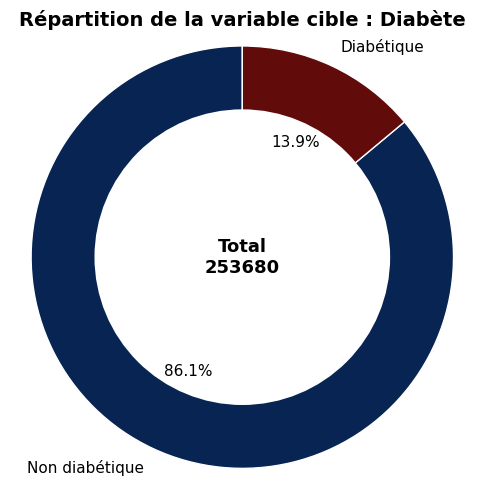

In [14]:
# Visualisation de la répartition de la variable cible 
counts = y.value_counts().sort_index()
labels = ["Non diabétique", "Diabétique"]

# Couleurs sobres et élégantes
colors = ["#072452", "#610B0B"]  # bleu / orange doux

fig, ax = plt.subplots(figsize=(5, 5))

wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor="white"),
    textprops=dict(color="black", fontsize=11)
)

# Cercle blanc au centre (donut propre)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

# Texte central
ax.text(
    0, 0,
    f"Total\n{counts.sum()}",
    ha='center',
    va='center',
    fontsize=13,
    fontweight='bold'
)

ax.set_title(
    "Répartition de la variable cible : Diabète",
    fontsize=14,
    fontweight='bold'
)

ax.axis('equal')

plt.tight_layout()
plt.savefig(
    "repartition_variable_cible_donut_clean.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


La répartition des modalités de la variable cible est très déséquilibrée. Seulement 14% des individus sont diabétiques pour 86% qui ne le sont pas. Nous verrons plus loin comment nous exploitons les données pour faire face à cela.

In [15]:
df.isna().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

Aucune valeur manquante détectée

In [16]:
np.isinf(df).sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(24206)

On a là 24206 doublons. A priori il s'agt d'observations dupliquées correspondant à des individus distincts. Elles seront donc conservées afin de préserver la distribution empirique des données et d’éviter l’introduction d’un biais artificiel.

In [18]:
## Quelques doublons

df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
4517,0,0,0,17,0,0,0,1,1,1,...,0,1,0,0,0,0,8,6,8,0
207307,0,0,0,17,0,0,0,1,1,1,...,0,1,0,0,0,0,8,6,8,0
42369,0,0,0,18,0,0,0,1,1,1,...,0,1,0,0,0,0,10,6,8,0
108949,0,0,0,18,0,0,0,1,1,1,...,0,1,0,0,0,0,10,6,8,0
17475,0,0,0,19,0,0,0,1,1,1,...,0,1,0,0,0,0,4,6,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246364,1,1,1,40,0,0,0,1,1,1,...,0,2,0,0,0,0,9,6,7,0
99426,1,1,1,40,0,0,0,1,1,1,...,0,3,0,0,0,0,9,6,7,0
157792,1,1,1,40,0,0,0,1,1,1,...,0,3,0,0,0,0,9,6,7,0
41565,1,1,1,43,0,0,0,1,0,1,...,0,3,0,0,0,0,8,6,8,0


### Modalités de chaque variable 

In [19]:
for col in df.columns:
    print(col, ":", sorted(df[col].dropna().unique()))


HighBP : [np.int64(0), np.int64(1)]
HighChol : [np.int64(0), np.int64(1)]
CholCheck : [np.int64(0), np.int64(1)]
BMI : [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74)

Les variables sont toutes binaires pour la plupart. Celles qui sont catégorielles comme education, age, income sont ordonnées. Donc nous avons jugé qu'il n'y a pas de raison de les diviser avec le One-hot incoder pour les modèles ensemblistes qui pourront alors tirer parti de cet ordre.

In [20]:
# liste des variables binaires 
binary = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex"
]

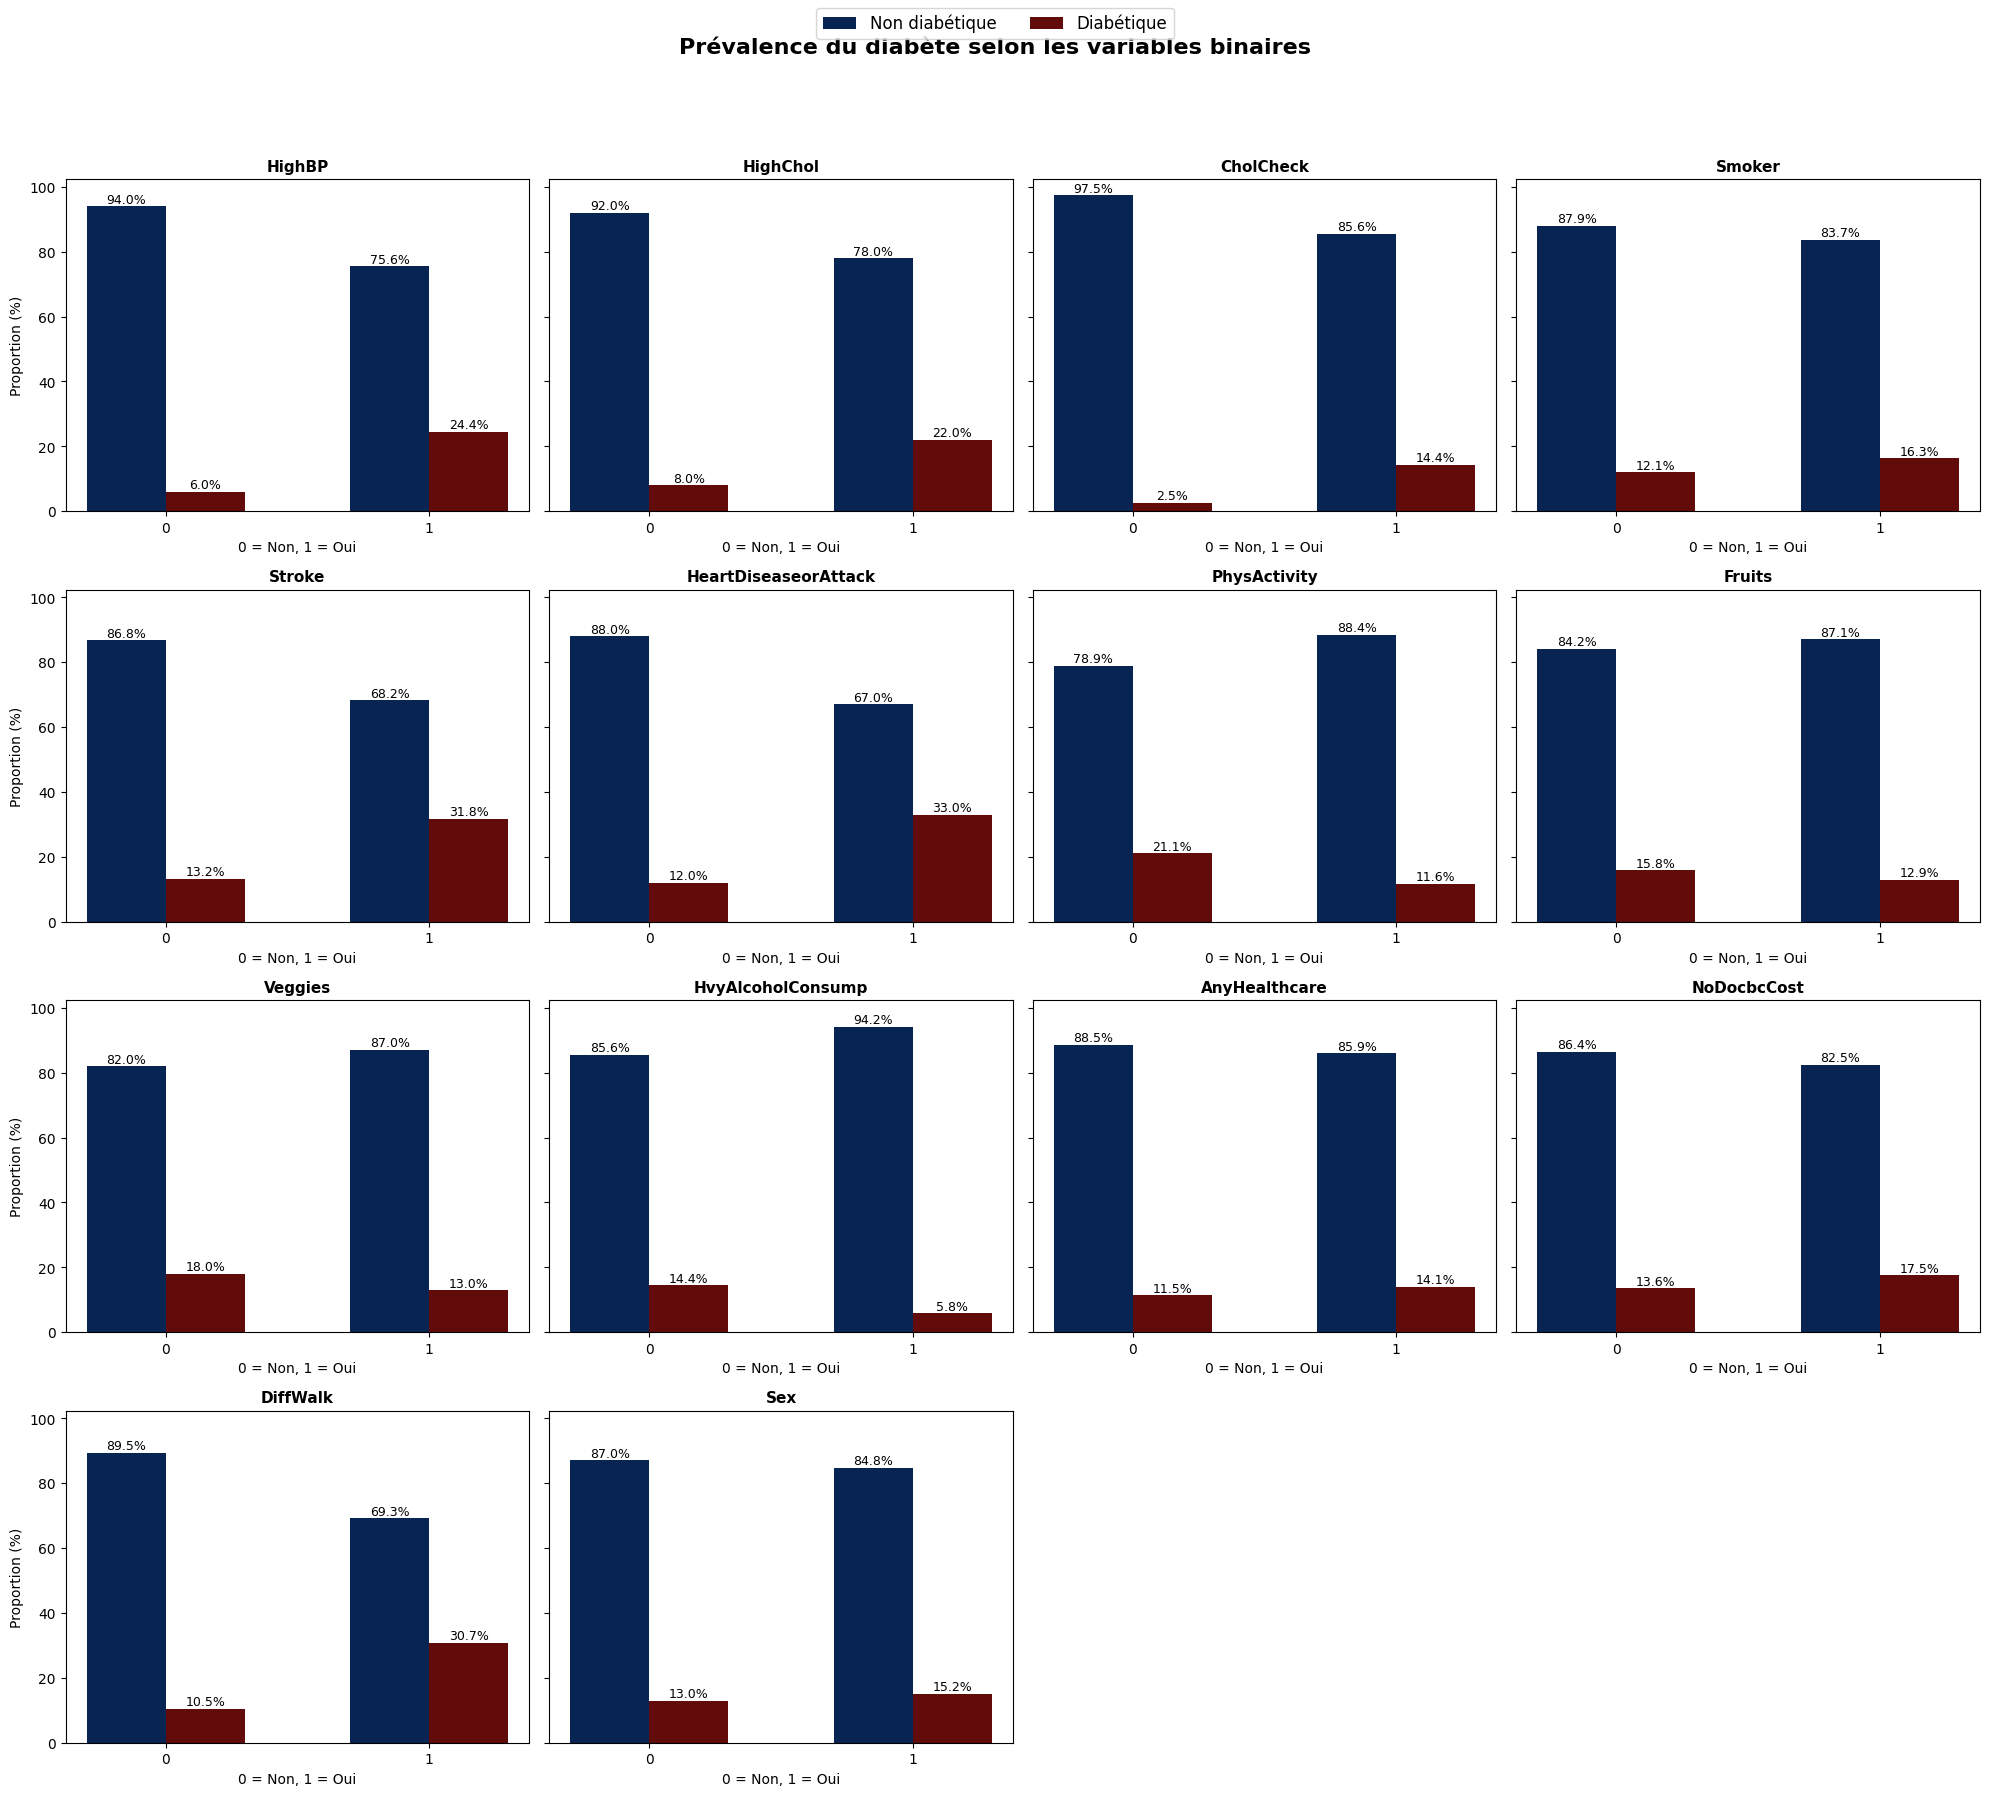

In [21]:
# Visualisation de la prévalence du diabète selon les variables binaires
n_vars = len(binary)
n_cols = 4
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(20, 4.5 * n_rows),
    sharey=True
)

axes = axes.flatten()

bar_width = 0.30          # ← largeur des barres (plus petit = plus fin)
x = np.arange(2)          # positions 0 et 1

for i, var in enumerate(binary):
    crosstab_pct = pd.crosstab(
        df[var],
        df["Diabetes_binary"],
        normalize="index"
    ) * 100

    ax = axes[i]

    # Barres rapprochées
    ax.bar(x - bar_width/2, crosstab_pct[0], width=bar_width,
           color="#072452", label="Non diabétique")
    ax.bar(x + bar_width/2, crosstab_pct[1], width=bar_width,
           color="#610B0B", label="Diabétique")

    # Ajout des pourcentages
    for j in range(2):
        ax.text(x[j] - bar_width/2, crosstab_pct.iloc[j, 0] + 1,
                f"{crosstab_pct.iloc[j, 0]:.1f}%", ha='center', fontsize=9)
        ax.text(x[j] + bar_width/2, crosstab_pct.iloc[j, 1] + 1,
                f"{crosstab_pct.iloc[j, 1]:.1f}%", ha='center', fontsize=9)

    ax.set_title(var, fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(["0", "1"])
    ax.set_xlabel("0 = Non, 1 = Oui")

    if i % n_cols == 0:
        ax.set_ylabel("Proportion (%)")

# Supprimer les axes inutilisés
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Légende globale
fig.legend(
    ["Non diabétique", "Diabétique"],
    loc="upper center",
    ncol=2,
    fontsize=12
)

fig.suptitle(
    "Prévalence du diabète selon les variables binaires",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


### Résultats – variables binaires

L’analyse descriptive met en évidence des **différences marquées de prévalence du diabète** selon plusieurs variables binaires liées à l’état de santé, aux comportements et aux conditions de vie des individus. Les **facteurs médicaux** apparaissent comme les plus fortement associés au diabète : l’hypertension artérielle, l’hypercholestérolémie, les antécédents cardiovasculaires et les difficultés de mobilité sont systématiquement associés à une prévalence nettement plus élevée du diabète.

Les **comportements de santé** montrent des résultats cohérents avec la littérature. L’activité physique régulière, ainsi que la consommation quotidienne de fruits et de légumes, sont associées à une prévalence plus faible du diabète, bien que ces effets restent modérés par rapport aux facteurs médicaux majeurs et puissent refléter un **mode de vie globalement plus sain**.

L’effet du tabagisme apparaît limité. En revanche, la **consommation excessive d’alcool** présente une association contre-intuitive avec une prévalence plus faible du diabète. Ce résultat ne doit pas être interprété de manière causale et s’explique vraisemblablement par des mécanismes de **causalité inversée**, des **effets de sélection** et un possible **effet de substitution entre alcool et boissons sucrées**, la consommation de sucre n’étant pas observée dans les données.

Les variables liées à l’**accès aux soins** indiquent qu’un meilleur suivi médical (tests de cholestérol) est associé à une prévalence plus élevée du diabète, tandis que les contraintes financières d’accès aux soins sont associées à une prévalence plus élevée, suggérant un **retard de diagnostic ou de prise en charge**. Enfin, les différences selon le sexe restent **modestes** comparées aux autres facteurs étudiés.


C:\Users\user\AppData\Local\Temp\ipykernel_33588\2162049097.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\user\AppData\Local\Temp\ipykernel_33588\2162049097.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\user\AppData\Local\Temp\ipykernel_33588\2162049097.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\user\AppData\Local\Temp\ipykernel_33588\2162049097.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

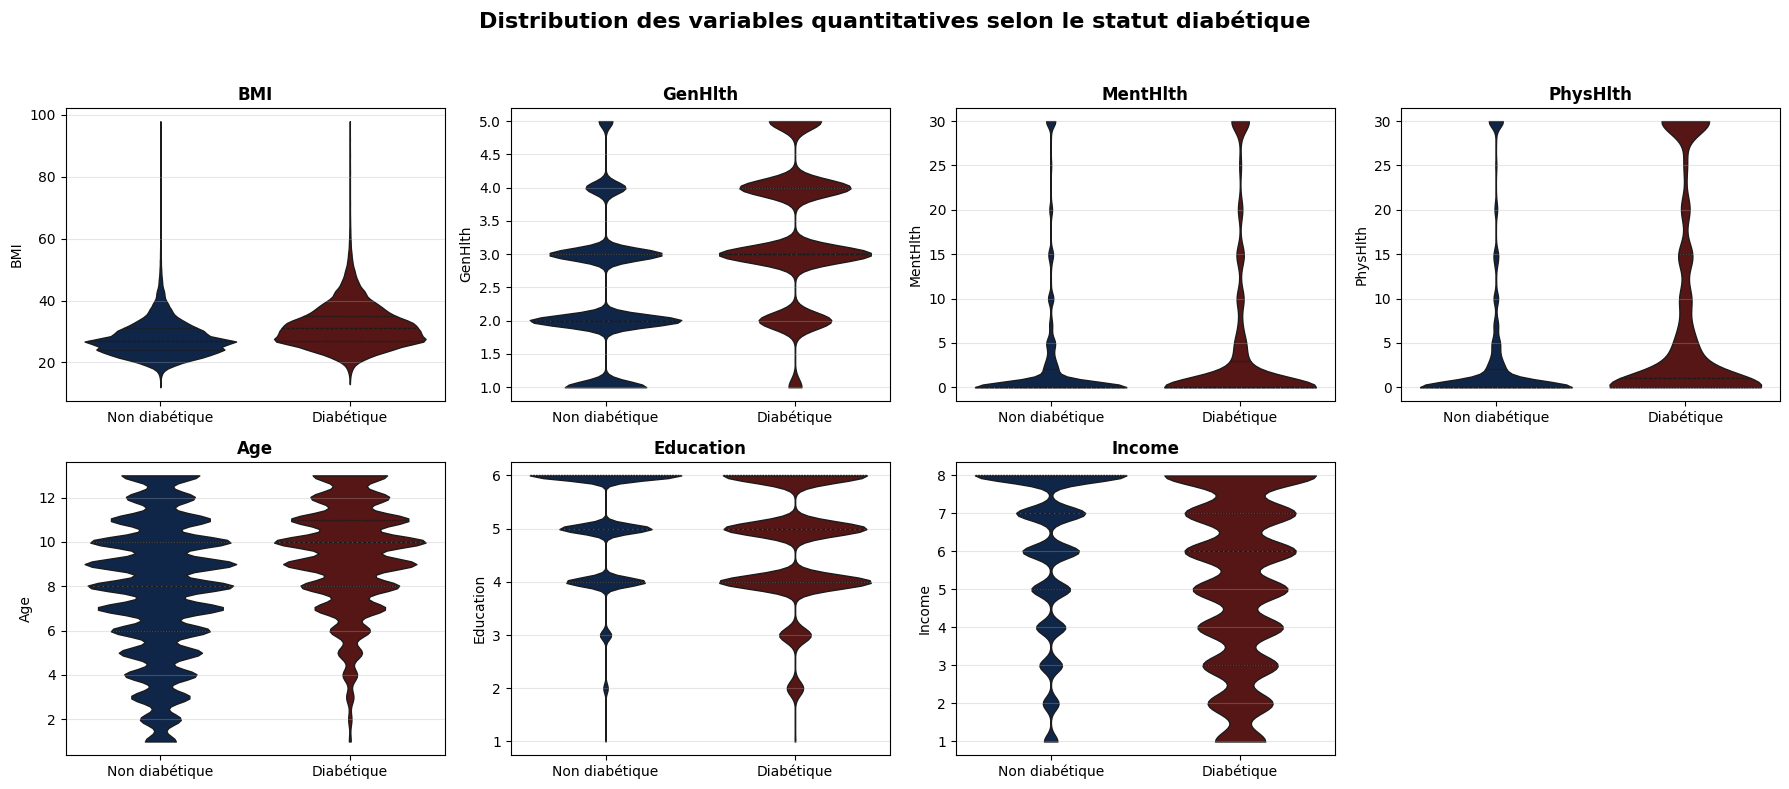

In [22]:
# Prévalence du diabète selon les variables quantitatives 
quant_vars = ["BMI", "GenHlth", "MentHlth", "PhysHlth", "Age", "Education", "Income"]

n_cols = 4
n_rows = int(np.ceil(len(quant_vars) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 8))
axes = axes.flatten()

for i, var in enumerate(quant_vars):
    sns.violinplot(
        data=df,
        x="Diabetes_binary",
        y=var,
        inner="quartile",
        cut=0,
        linewidth=1,
        palette=["#072452", "#610B0B"],
        ax=axes[i]
    )
    axes[i].set_title(var, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Non diabétique", "Diabétique"])
    axes[i].grid(axis="y", alpha=0.3)

# Supprimer les axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Distribution des variables quantitatives selon le statut diabétique",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [23]:
# Moyennes par statut diabétique
means = df.groupby("Diabetes_binary")[quant_vars].mean()

# Différence et ratio
comparison = pd.DataFrame({
    "Mean (Non diabétique)": means.loc[0],
    "Mean (Diabétique)": means.loc[1],
    "Difference (Diabétique - Non)": means.loc[1] - means.loc[0],
    "Ratio (Diabétique / Non)": means.loc[1] / means.loc[0]
})

# Arrondir pour lisibilité
comparison = comparison.round(2)

display(comparison)


,Mean (Non diabétique),Mean (Diabétique),Difference (Diabétique - Non),Ratio (Diabétique / Non)
BMI,27.81,31.94,4.14,1.15
GenHlth,2.39,3.29,0.91,1.38
MentHlth,2.98,4.46,1.48,1.50
PhysHlth,3.64,7.95,4.31,2.18
Age,7.81,9.38,1.56,1.20
Education,5.10,4.75,-0.35,0.93
Income,6.19,5.21,-0.98,0.84


### Résultats – variables quantitatives et catégorielles ordonnées

L’analyse des distributions met en évidence des **différences nettes et cohérentes** entre les individus diabétiques et non diabétiques pour plusieurs variables quantitatives. Les écarts les plus marqués concernent le **BMI**, l’**âge**, l’**état de santé général** et la **santé physique**. Les individus diabétiques présentent en moyenne un BMI plus élevé, appartiennent plus fréquemment à des tranches d’âge supérieures et déclarent un état de santé général plus dégradé, ainsi qu’un nombre plus important de jours de mauvaise santé physique.

Les variables de **santé mentale** montrent des différences plus modérées, bien que les diabétiques présentent une dispersion plus importante et des valeurs extrêmes plus fréquentes. Les variables **socio-économiques**, telles que le niveau d’éducation et le revenu, indiquent également un gradient en défaveur des individus diabétiques, mais avec un chevauchement important entre les distributions, suggérant un **effet indirect** plutôt qu’un facteur déterminant isolé.

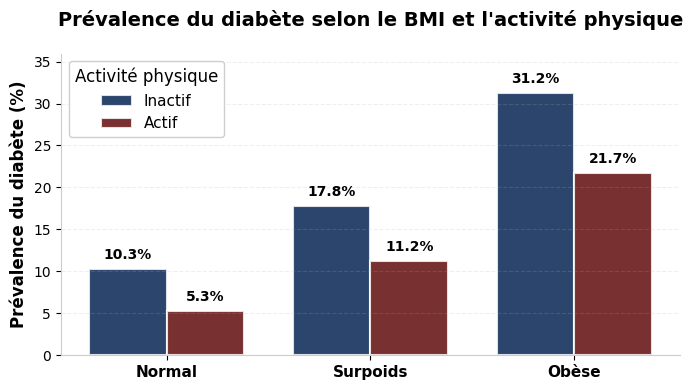

In [24]:
# Prévalence du diabète selon le BMI et l'activité physique
# Catégoriser BMI
df["BMI_cat"] = pd.cut(
    df["BMI"],
    bins=[0, 25, 30, 100],
    labels=["Normal", "Surpoids", "Obèse"]
)

# Prévalence du diabète (%)
bmi_pa = (
    pd.crosstab(
        [df["BMI_cat"], df["PhysActivity"]],
        df["Diabetes_binary"],
        normalize="index"
    ) * 100
).reset_index()

bmi_pa = bmi_pa.rename(columns={1: "Diabète"})
bmi_pa["PhysActivity"] = bmi_pa["PhysActivity"].map({0: "Inactif", 1: "Actif"})

# Élégant bar chart
fig, ax = plt.subplots(figsize=(7, 4))

cats = bmi_pa["BMI_cat"].unique()
x = np.arange(len(cats))
width = 0.38

# Couleurs sobres et élégantes
colors = ["#072452", "#610B0B"]

for i, activity in enumerate(["Inactif", "Actif"]):
    vals = bmi_pa[bmi_pa["PhysActivity"] == activity]["Diabète"].values
    bars = ax.bar(x + i * width, vals, width, label=activity, color=colors[i], alpha=0.85, edgecolor="white", linewidth=1.5)
    ax.bar_label(bars, fmt="%.1f%%", padding=5, fontsize=10, fontweight="bold")

ax.set_xticks(x + width / 2)
ax.set_xticklabels(cats, fontsize=11, fontweight="bold")
ax.set_ylabel("Prévalence du diabète (%)", fontsize=12, fontweight="bold")
ax.set_title("Prévalence du diabète selon le BMI et l'activité physique", fontsize=14, fontweight="bold", pad=20)
ax.legend(title="Activité physique", fontsize=11, title_fontsize=12, loc="upper left", framealpha=0.95)
ax.grid(axis="y", alpha=0.2, linestyle="--")
ax.set_ylim(0, max(bmi_pa["Diabète"].values) * 1.15)

# Ajouter une bordure élégante
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

plt.tight_layout()
plt.savefig("prevalence_diabete_bmi_activite.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

Ce graphique montre clairement que la prévalence du diabète augmente fortement avec l'indice de masse corporelle, passant d’un niveau faible chez les individus de corpulence normale à un niveau très élevé chez les personnes obèses. À chaque niveau de BMI, les individus physiquement actifs présentent systématiquement une prévalence plus faible du diabète que les individus inactifs, ce qui suggère que l’activité physique atténue, sans l’annuler, le risque associé au surpoids et à l’obésité.


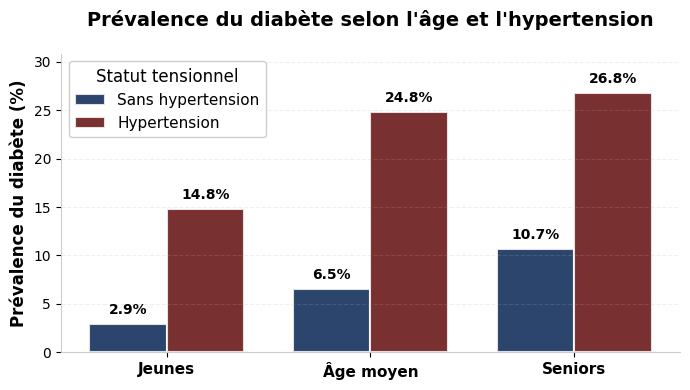

In [25]:
# Prévalence du diabète selon l'âge et l'hypertension
# Catégoriser l'âge
df["Age_cat"] = pd.cut(
    df["Age"],
    bins=[0, 6, 9, 13],
    labels=["Jeunes", "Âge moyen", "Seniors"]
)

# Prévalence du diabète (%)
age_bp = (
    pd.crosstab(
        [df["Age_cat"], df["HighBP"]],
        df["Diabetes_binary"],
        normalize="index"
    ) * 100
).reset_index()

age_bp = age_bp.rename(columns={1: "Diabète"})
age_bp["HighBP"] = age_bp["HighBP"].map({0: "Sans hypertension", 1: "Hypertension"})

# Élégant bar chart
fig, ax = plt.subplots(figsize=(7, 4))

cats = age_bp["Age_cat"].unique()
x = np.arange(len(cats))
width = 0.38

colors = ["#072452", "#610B0B"]

for i, bp in enumerate(["Sans hypertension", "Hypertension"]):
    vals = age_bp[age_bp["HighBP"] == bp]["Diabète"].values
    bars = ax.bar(x + i * width, vals, width, label=bp, color=colors[i], alpha=0.85, edgecolor="white", linewidth=1.5)
    ax.bar_label(bars, fmt="%.1f%%", padding=5, fontsize=10, fontweight="bold")

ax.set_xticks(x + width / 2)
ax.set_xticklabels(cats, fontsize=11, fontweight="bold")
ax.set_ylabel("Prévalence du diabète (%)", fontsize=12, fontweight="bold")
ax.set_title("Prévalence du diabète selon l'âge et l'hypertension", fontsize=14, fontweight="bold", pad=20)
ax.legend(title="Statut tensionnel", fontsize=11, title_fontsize=12, loc="upper left", framealpha=0.95)
ax.grid(axis="y", alpha=0.2, linestyle="--")
ax.set_ylim(0, max(age_bp["Diabète"].values) * 1.15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

plt.tight_layout()
plt.savefig("prevalence_diabete_age_hypertension.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

Nous observons une augmentation marquée de la prévalence du diabète avec l’âge, aussi bien chez les individus hypertendus que non hypertendus. À tous les âges, l’hypertension est associée à une prévalence du diabète nettement plus élevée, suggérant un effet cumulatif de l’âge et de l’hypertension sur le risque de diabète.


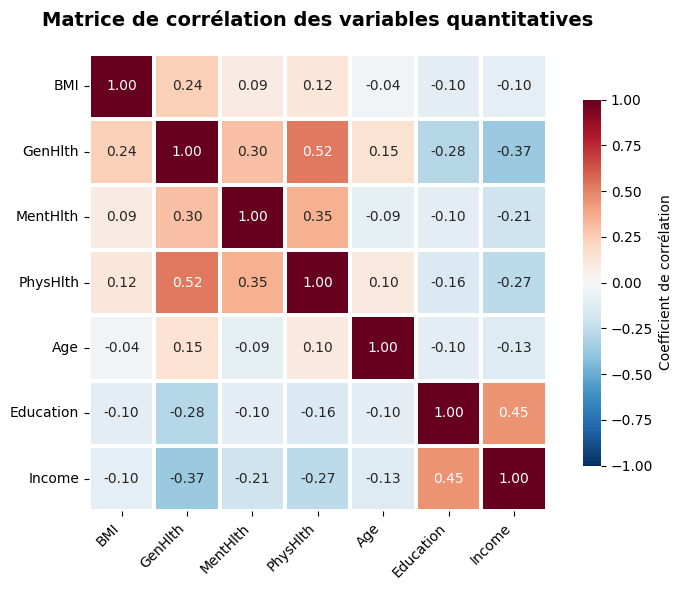

In [26]:
# Matrice de corrélation (Pearson)
corr_matrix = df[quant_vars].corr()

# Heatmap élégante
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=1.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Coefficient de corrélation"},
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax
)

# Styling
ax.set_title(
    "Matrice de corrélation des variables quantitatives",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

La matrice de corrélation révèle des relations modérées et cohérentes entre les variables de santé, ainsi qu’un gradient socio-économique (caractérisé par une amélioration progressive des indicateurs de santé à mesure que le niveau d’éducation et de revenu augmente) marqué, sans mettre en évidence de multicolinéarité sévère. Ces résultats confirment la pertinence de l’ensemble des variables pour une modélisation multivariée du diabète.

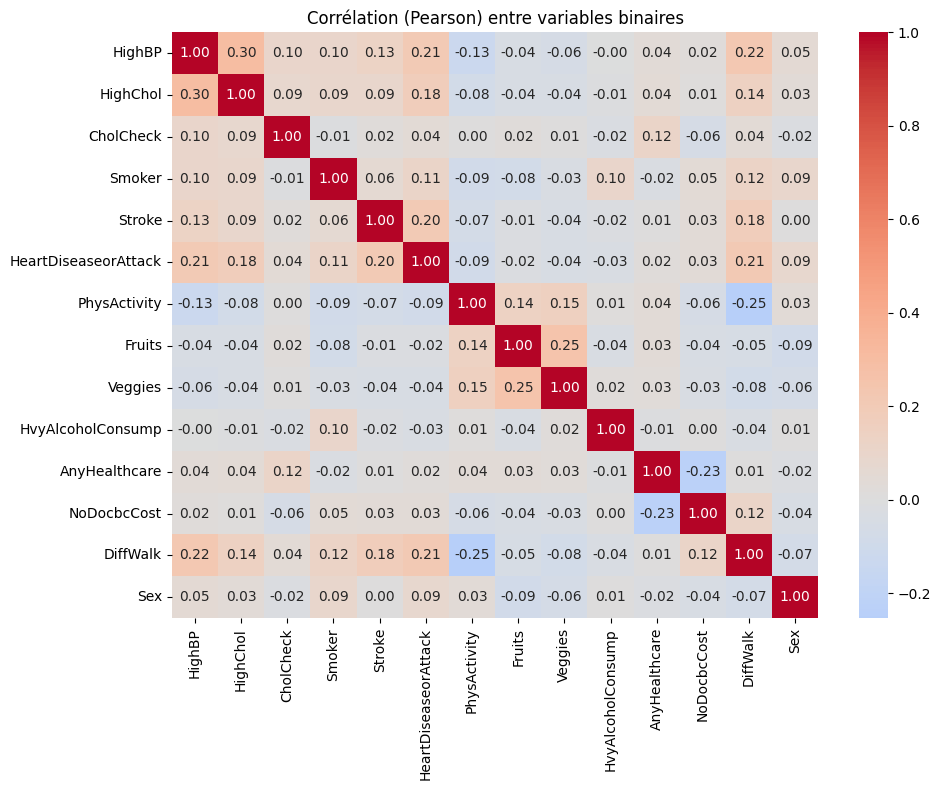

In [27]:
# Matrice de corrélation (Pearson) entre variables binaires
corr_bin = df[binary].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_bin,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Corrélation (Pearson) entre variables binaires")
plt.tight_layout()
plt.show()


Les corrélations entre les variables binaires restent globalement faibles. Dans l’ensemble, l’absence de corrélations élevées suggère qu’il n’y a pas de redondance excessive entre les variables, ce qui permet de les utiliser conjointement dans nos modèle.

In [28]:
# Suppression des colonnes catégorielles créées lors de l'exploration
df = df.drop(columns=['BMI_cat', 'Age_cat'])

### <span style="color:#4D4D4D; font-weight:bold;">ML MODELS</span>



In [29]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression



# -------------------------
# 1) Split X / y
# -------------------------
target = "Diabetes_binary"

X = df.drop(columns=[target, "ID"], errors="ignore")  # ID inutile, errors="ignore" au cas où
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

 #### <span style="color:#B7950B; font-weight:bold;"> I) K-Nearest Neighbors (k-NN)</span>
Méthode de classification non paramétrique qui prédit la classe d’une observation à partir de la classe majoritaire parmi ses k voisins les plus proches dans l’espace des variables explicatives. Ne reposant sur aucune hypothèse de forme fonctionnelle, il constitue un point de comparaison simple et intuitif pour évaluer les performances des modèles plus structurés



In [33]:
# -------------------------
# 1) Pipeline: scaling + KNN
# -------------------------
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# Grid of k values 
param_grid = {
    "knn__n_neighbors": list(range(1, 10, 2)),  # k impair pour éviter les égalités
}

grid = GridSearchCV(
    pipe_knn,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best hyperparameters:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))


Best hyperparameters: {'knn__n_neighbors': 9}
Best CV accuracy: 0.8562



Test accuracy: 0.8547

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92     43667
           1       0.45      0.17      0.25      7069

    accuracy                           0.85     50736
   macro avg       0.66      0.57      0.59     50736
weighted avg       0.82      0.85      0.83     50736



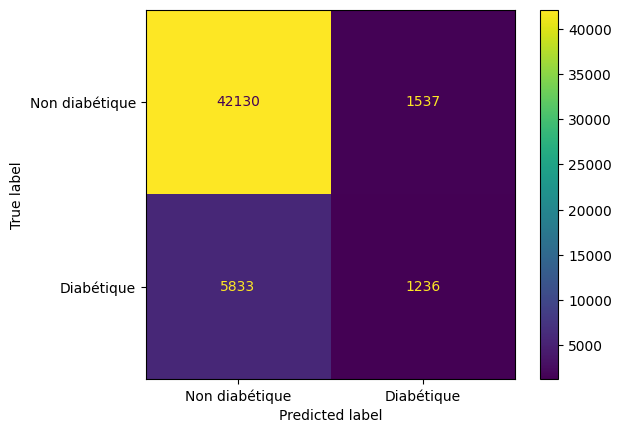

In [34]:
# -------------------------
# 2) Evaluation on test
# -------------------------
best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)

print("\nTest accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non diabétique", "Diabétique"])
disp.plot()

 #### <span style="color:#B7950B; font-weight:bold;"> II) Decision Tree</span>

In [35]:

# -------------------------
# 1) Decision Tree + GridSearch
# -------------------------
dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 10, 50, 100],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"]
}

grid_dt = GridSearchCV(
    dt,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best hyperparameters:", grid_dt.best_params_)
print("Best CV accuracy:", round(grid_dt.best_score_, 4))


Best hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV accuracy: 0.7993



Test accuracy: 0.7958

Classification report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88     43667
           1       0.29      0.32      0.30      7069

    accuracy                           0.80     50736
   macro avg       0.59      0.60      0.59     50736
weighted avg       0.80      0.80      0.80     50736



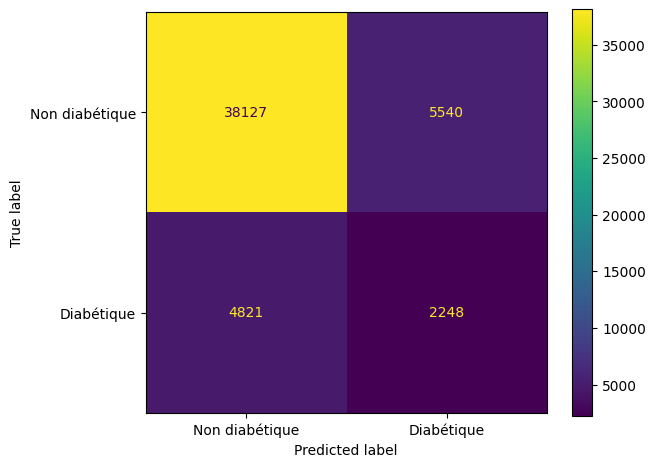

In [36]:
# -------------------------
# 2) Evaluation on test
# -------------------------
best_dt = grid_dt.best_estimator_
y_pred = best_dt.predict(X_test)

print("\nTest accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non diabétique", "Diabétique"])
disp.plot()
plt.tight_layout()
plt.show()

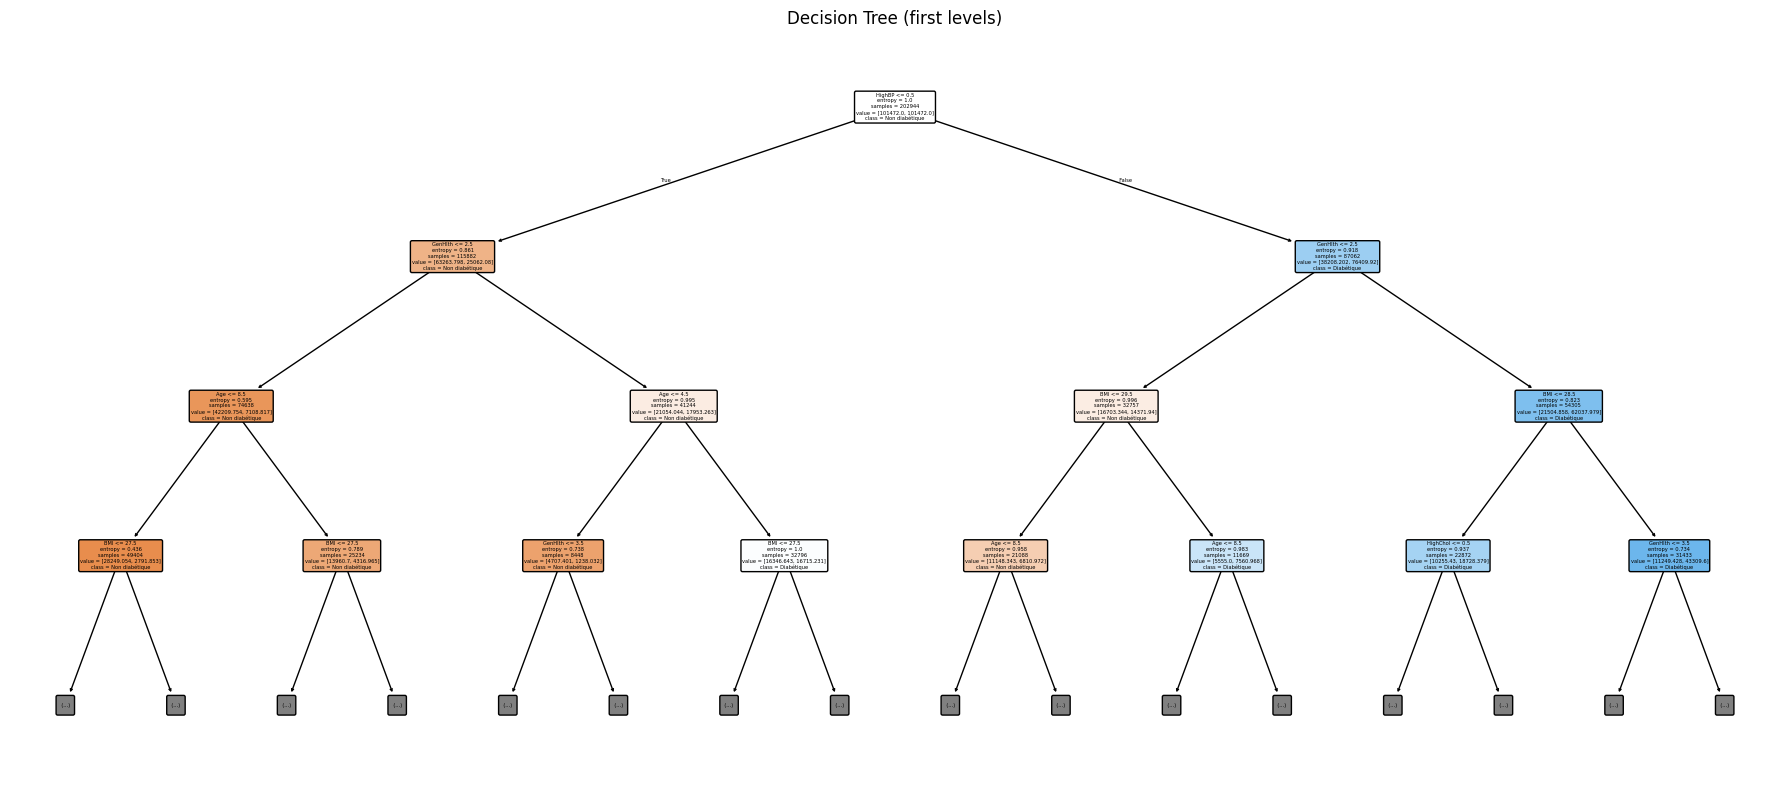

In [37]:

# -------------------------
# 3) Visualisation de l'arbre
# -------------------------
plt.figure(figsize=(18, 8))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["Non diabétique", "Diabétique"],
    filled=True,
    rounded=True,
    max_depth=3  # Affiche seulement les premiers niveaux pour la lisibilité
)
plt.title("Decision Tree (first levels)")
plt.tight_layout()
plt.show()


 #### <span style="color:#B7950B; font-weight:bold;"> III) Logistic regression</span>

In [38]:
# -------------------------
# 2) Pipeline: scaling + logistic regression (balanced)
# -------------------------
pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42))
])

# Hyperparameter search (regularization strength C)
param_grid = {
    "logreg__C": np.logspace(-4, 4, 9),   
    "logreg__penalty": ["l2"],
    "logreg__solver": ["lbfgs"]
}

grid_log = GridSearchCV(
    pipe_log,
    param_grid,
    cv=5,
    scoring="f1",      # mieux adapté que l'accuracy si classes déséquilibrées
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

print("Best hyperparameters:", grid_log.best_params_)
print("Best CV F1:", round(grid_log.best_score_, 4))

best_log = grid_log.best_estimator_

c:\Users\user\Documents\GitHub\Applied-Statistical-Learning-Projet-\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best hyperparameters: {'logreg__C': np.float64(0.001), 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
Best CV F1: 0.4434



Test accuracy: 0.7314
Test ROC-AUC: 0.8197

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.73      0.82     43667
           1       0.31      0.76      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.73      0.77     50736



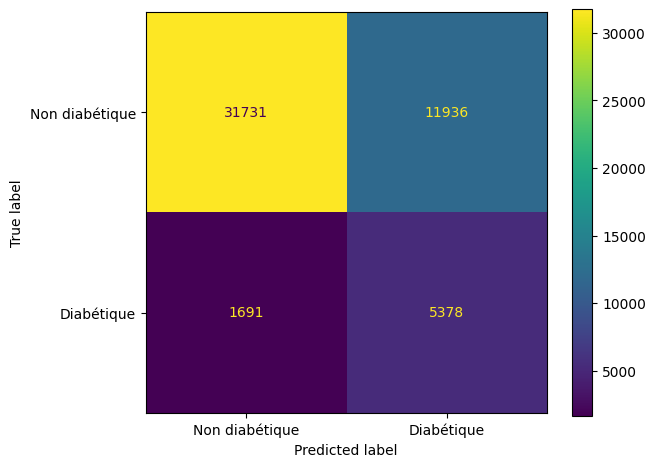

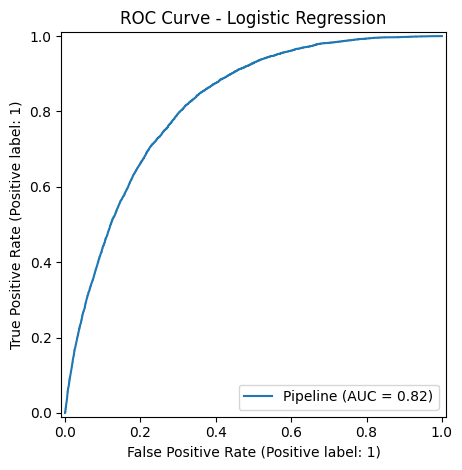

In [39]:
# -------------------------
# 3) Evaluation on test
# -------------------------
y_pred = best_log.predict(X_test)
y_proba = best_log.predict_proba(X_test)[:, 1]

print("\nTest accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non diabétique", "Diabétique"])
disp.plot()
plt.tight_layout()
plt.show()

RocCurveDisplay.from_estimator(best_log, X_test, y_test)
plt.title("ROC Curve - Logistic Regression")
plt.tight_layout()
plt.show()

In [40]:
# -------------------------
# 4) Odds ratios (interpretation)
# -------------------------
# Récupérer le modèle entraîné
log_model = best_log.named_steps["logreg"]
feature_names = X.columns

coef = log_model.coef_.ravel()
odds_ratios = np.exp(coef)

or_table = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "odds_ratio": odds_ratios
}).sort_values("odds_ratio", ascending=False)

print("\nTop variables (odds ratios):")
display(or_table.head(15).round(4))


Top variables (odds ratios):


,feature,coef,odds_ratio
13,GenHlth,0.5897,1.8035
3,BMI,0.4725,1.6040
18,Age,0.4350,1.5450
0,HighBP,0.3618,1.4359
1,HighChol,0.2826,1.3266
2,CholCheck,0.2301,1.2587
17,Sex,0.1337,1.1431
6,HeartDiseaseorAttack,0.0766,1.0796
16,DiffWalk,0.0436,1.0446
5,Stroke,0.0378,1.0386


 #### <span style="color:#B7950B; font-weight:bold;"> IV) Random Forest</span>

In [41]:

# 1) Random Forest (balanced)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",   # très important ici
    n_jobs=-1
)

param_grid = {   
    "max_depth": [None, 15],            # 2 options
    "min_samples_leaf": [1, 10],        # 2 options
    "max_features": ["sqrt"]            # 1 option
}


grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1",      # mieux que l’accuracy pour classes déséquilibrées
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best hyperparameters:", grid_rf.best_params_)
print("Best CV F1:", round(grid_rf.best_score_, 4))

best_rf = grid_rf.best_estimator_


Best hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Best CV F1: 0.4596



Test accuracy: 0.7661
Test ROC-AUC: 0.8238

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.78      0.85     43667
           1       0.34      0.71      0.46      7069

    accuracy                           0.77     50736
   macro avg       0.64      0.74      0.65     50736
weighted avg       0.86      0.77      0.80     50736



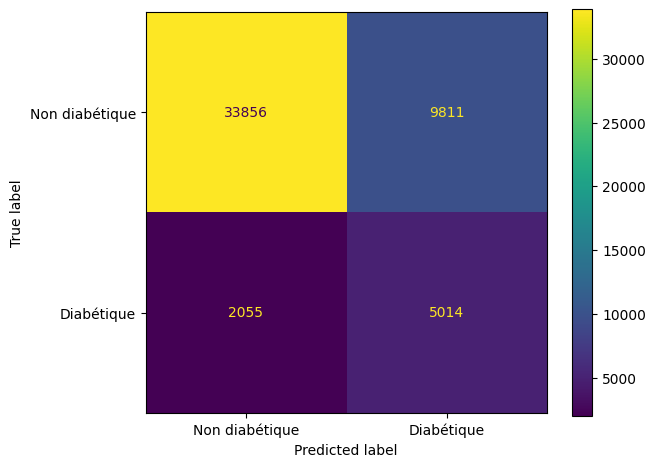

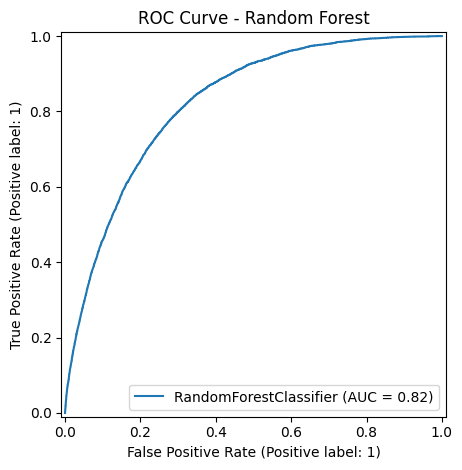

In [42]:
# -------------------------
# 2) Evaluation on test
# -------------------------
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print("\nTest accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non diabétique", "Diabétique"]
)
disp.plot()
plt.tight_layout()
plt.show()

RocCurveDisplay.from_estimator(best_rf, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.tight_layout()
plt.show()


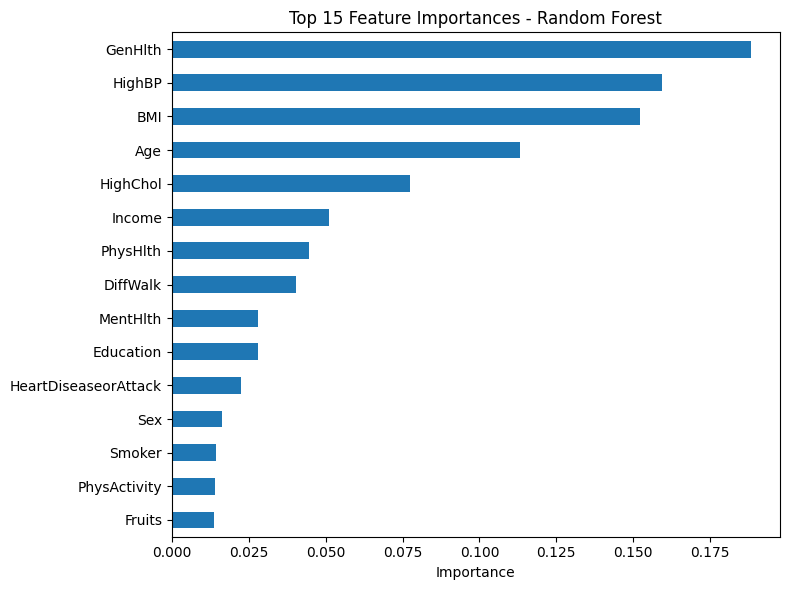

GenHlth                 0.1883
HighBP                  0.1595
BMI                     0.1521
Age                     0.1133
HighChol                0.0774
Income                  0.0512
PhysHlth                0.0447
DiffWalk                0.0405
MentHlth                0.0279
Education               0.0279
HeartDiseaseorAttack    0.0225
Sex                     0.0164
Smoker                  0.0143
PhysActivity            0.0142
Fruits                  0.0137
dtype: float64

In [43]:
# -------------------------
# 3) Feature importance
# -------------------------
importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(importances.head(15).round(4))

 #### <span style="color:#B7950B; font-weight:bold;"> V) AdaBoost </span> 

In [44]:
# -------------------------
# 2) Pondérations pour gérer le déséquilibre des classes
# -------------------------
class_counts = y_train.value_counts()
w0 = 1.0 / class_counts[0]
w1 = 1.0 / class_counts[1]
sample_weight = y_train.map({0: w0, 1: w1}).values

# -------------------------
# 3) AdaBoost + GridSearchCV
# -------------------------
base_tree = DecisionTreeClassifier(random_state=42)

ada = AdaBoostClassifier(
    estimator=base_tree,
    random_state=42
)

param_grid = {
    "estimator__max_depth": [1, 2],      # stump vs slightly deeper
    "n_estimators": [150, 300],          # keep small to control runtime
    "learning_rate": [0.05, 0.1, 0.2]    # standard range
}

grid_ada = GridSearchCV(
    ada,
    param_grid,
    cv=3,                 # cv=3 for speed with large dataset
    scoring="f1",       
    n_jobs=-1
)

grid_ada.fit(X_train, y_train, sample_weight=sample_weight)

print("Best params:", grid_ada.best_params_)
print("Best CV F1:", round(grid_ada.best_score_, 4))

best_ada = grid_ada.best_estimator_



Best params: {'estimator__max_depth': 2, 'learning_rate': 0.2, 'n_estimators': 300}
Best CV F1: 0.7548



Test accuracy: 0.7348
Test ROC-AUC: 0.8233

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.73      0.83     43667
           1       0.31      0.76      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.75      0.64     50736
weighted avg       0.86      0.73      0.77     50736



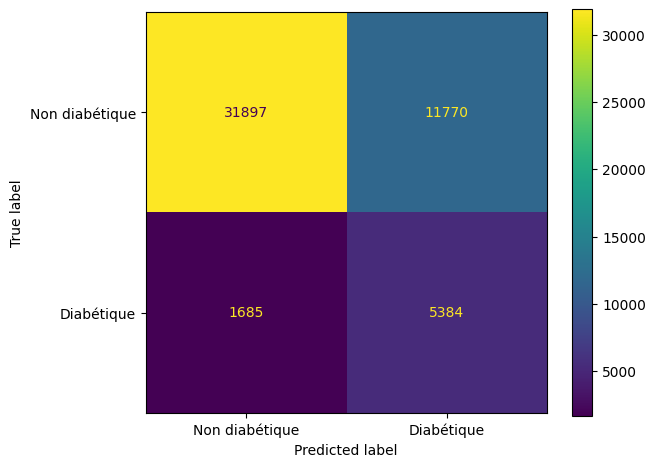

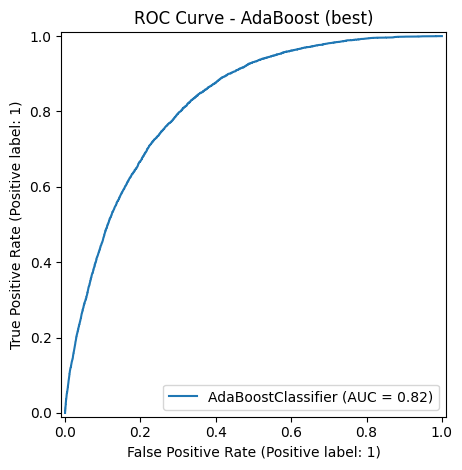

In [45]:
# -------------------------
# 4) Evaluation on test
# -------------------------
y_pred = best_ada.predict(X_test)
y_proba = best_ada.predict_proba(X_test)[:, 1]

print("\nTest accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Non diabétique", "Diabétique"]).plot()
plt.tight_layout()
plt.show()

RocCurveDisplay.from_estimator(best_ada, X_test, y_test)
plt.title("ROC Curve - AdaBoost (best)")
plt.tight_layout()
plt.show()

 #### <span style="color:#B7950B; font-weight:bold;"> VI) Multi-Layer Perceptron </span> 

c:\Users\user\Documents\GitHub\Applied-Statistical-Learning-Projet-\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'mlp__alpha': 0.0001, 'mlp__batch_size': 512, 'mlp__hidden_layer_sizes': (64,), 'mlp__learning_rate_init': 0.001}
Best CV F1: 0.4397

Test accuracy: 0.72
Test ROC-AUC: 0.8227

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.71      0.81     43667
           1       0.30      0.79      0.44      7069

    accuracy                           0.72     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.72      0.76     50736



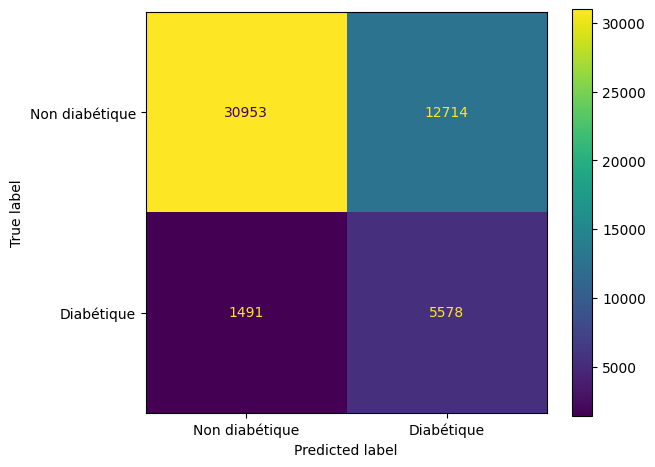

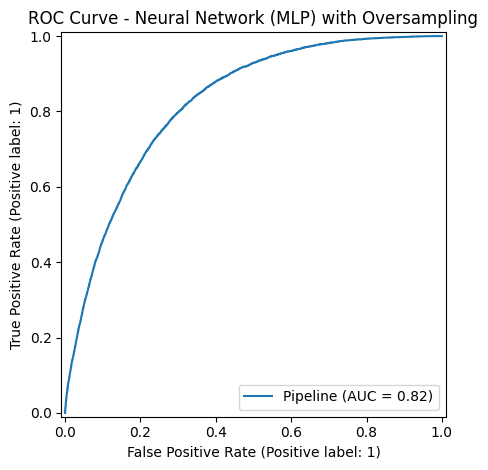

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, accuracy_score
)

from imblearn.pipeline import Pipeline              # IMPORTANT: pipeline imblearn
from imblearn.over_sampling import RandomOverSampler

# -------------------------
# 1) Split X / y
# -------------------------
target = "Diabetes_binary"
X = df.drop(columns=[target, "ID"], errors="ignore")
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# 2) Pipeline: scaler -> oversampling -> MLP
# -------------------------
pipe_mlp_bal = Pipeline([
    ("scaler", StandardScaler()),
    ("ros", RandomOverSampler(random_state=42)),
    ("mlp", MLPClassifier(
        random_state=42,
        early_stopping=True,
        n_iter_no_change=10,
        validation_fraction=0.2,
        max_iter=200
    ))
])

# -------------------------
# 3) Grid raisonnable (rapide)
# -------------------------
param_grid = {
    "mlp__hidden_layer_sizes": [(64,), (128,), (128, 64)],
    "mlp__alpha": [1e-4, 1e-3],
    "mlp__learning_rate_init": [1e-3],
    "mlp__batch_size": [512]
}

grid_mlp = GridSearchCV(
    pipe_mlp_bal,
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_mlp.fit(X_train, y_train)

print("Best params:", grid_mlp.best_params_)
print("Best CV F1:", round(grid_mlp.best_score_, 4))

best_mlp = grid_mlp.best_estimator_

# -------------------------
# 4) Evaluation on test
# -------------------------
y_pred = best_mlp.predict(X_test)
y_proba = best_mlp.predict_proba(X_test)[:, 1]

print("\nTest accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Non diabétique", "Diabétique"]).plot()
plt.tight_layout()
plt.show()

RocCurveDisplay.from_estimator(best_mlp, X_test, y_test)
plt.title("ROC Curve - Neural Network (MLP) with Oversampling")
plt.tight_layout()
plt.show()
